In [1]:
import train
%load_ext autoreload
%autoreload 2
import tools
from analysis import performance
from analysis import standard_analysis
from analysis import clustering
from analysis import variance
from analysis import taskset
from analysis import varyhp
from analysis import data_analysis
from analysis import contextdm_analysis
from analysis import posttrain_analysis
from network import Model
import tensorflow as tf
import numpy as np
import random as random
import os
import matplotlib.pyplot as plt

/home/fbraidi/miniconda3/envs/thesis-env/lib/python3.7/site-packages/tensorflow/python/framework/dtypes.py:526: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
/home/fbraidi/miniconda3/envs/thesis-env/lib/python3.7/site-packages/tensorflow/python/framework/dtypes.py:527: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
/home/fbraidi/miniconda3/envs/thesis-env/lib/python3.7/site-packages/tensorflow/python/framework/dtypes.py:528: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
/home/fbraidi/miniconda3/env

In [20]:
model_dir='./../models/fdanti_delaygo_fdgo_delaydm1_dm1_delaydm2_dm2_contextdelaydm1_contextdm1_contextdelaydm2_dm2_multidelaydm_multidm_1024'
replace_rule= ['fdgo', 'reactgo', 'delaygo', 'fdanti', 'reactanti', 'delayanti',
              'dm1', 'dm2', 'contextdm1', 'contextdm2', 'multidm',
              'delaydm1', 'delaydm2', 'contextdelaydm1', 'contextdelaydm2', 'multidelaydm',
              'dmsgo', 'dmsnogo', 'dmcgo', 'dmcnogo', 'random', 'random_mod']

compositional_rules={'go':[-1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
                     'dm1':[0,0,0,1,0,0,-1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0],
                     'dm2':[0,0,0,1,0,0,0,-1,0,0,0,0,1,0,0,0,0,0,0,0,0,0],
                     'contextdm1':[0,0,0,1,0,0,0,0,-1,0,0,0,0,1,0,0,0,0,0,0,0,0],
                     'contextdm2':[0,0,0,1,0,0,0,0,0,-1,0,0,0,0,1,0,0,0,0,0,0,0],
                     'multidm':[0,0,0,1,0,0,0,0,0,0,-1,0,0,0,0,1,0,0,0,0,0,0]}

pure_tasks_perfs=[]
comp_tasks_perf=[]

for i in range(len(replace_rule)):

    rule_strength=[0]*len(replace_rule)
    rule_strength[i]=1
    perf, _ = taskset.run_network_replacerule(model_dir, replace_rule[i], replace_rule, rule_strength)
    pure_tasks_perfs.append(perf)

for el in compositional_rules:

    perf, _ = taskset.run_network_replacerule(model_dir, 'delayanti', replace_rule, compositional_rules[el])
    comp_tasks_perf.append((el,perf))

for i in range(len(replace_rule)):

    print(f'Performance on task {replace_rule[i]}: ', pure_tasks_perfs[i])

for (fam,perf) in comp_tasks_perf:

    print(f'Performance on delayanti when instructed with {fam} family: ', perf)

INFO:tensorflow:Restoring parameters from ./../models/fdanti_delaygo_fdgo_delaydm1_dm1_delaydm2_dm2_contextdelaydm1_contextdm1_contextdelaydm2_dm2_multidelaydm_multidm_1024/model.ckpt
Model restored from file: ./../models/fdanti_delaygo_fdgo_delaydm1_dm1_delaydm2_dm2_contextdelaydm1_contextdm1_contextdelaydm2_dm2_multidelaydm_multidm_1024/model.ckpt
INFO:tensorflow:Restoring parameters from ./../models/fdanti_delaygo_fdgo_delaydm1_dm1_delaydm2_dm2_contextdelaydm1_contextdm1_contextdelaydm2_dm2_multidelaydm_multidm_1024/model.ckpt
Model restored from file: ./../models/fdanti_delaygo_fdgo_delaydm1_dm1_delaydm2_dm2_contextdelaydm1_contextdm1_contextdelaydm2_dm2_multidelaydm_multidm_1024/model.ckpt
INFO:tensorflow:Restoring parameters from ./../models/fdanti_delaygo_fdgo_delaydm1_dm1_delaydm2_dm2_contextdelaydm1_contextdm1_contextdelaydm2_dm2_multidelaydm_multidm_1024/model.ckpt
Model restored from file: ./../models/fdanti_delaygo_fdgo_delaydm1_dm1_delaydm2_dm2_contextdelaydm1_contextdm1_c

In [26]:
import numpy as np
from analysis import taskset
import os

model_dir='./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024'
replace_rule= ['fdgo', 'reactgo', 'delaygo', 'fdanti', 'reactanti', 'delayanti',
              'dm1', 'dm2', 'contextdm1', 'contextdm2', 'multidm',
              'delaydm1', 'delaydm2', 'contextdelaydm1', 'contextdelaydm2', 'multidelaydm',
              'dmsgo', 'dmsnogo', 'dmcgo', 'dmcnogo', 'random', 'random_mod']

grid=np.linspace(-5,5,11)

performances=np.zeros(shape=(11,11))

for i,a in enumerate(grid):
    for j,b in enumerate(grid):

        rule_strength= a*np.array([-1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0])+\
                        b*np.array([0,0,0,1,0,0,-1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0])
                        
        perf, _ = taskset.run_network_replacerule(model_dir, 'delayanti', replace_rule, rule_strength)
        performances[i,j]=perf

np.save(os.path.join(model_dir,'comp_rule_linear_comb_neg.npy'),performances)
        


-5.0 -5.0
[  5.  -0.  -5. -10.  -0.  -0.   5.  -0.  -0.  -0.  -0.  -5.  -0.  -0.
  -0.  -0.  -0.  -0.  -0.  -0.  -0.  -0.]
INFO:tensorflow:Restoring parameters from ./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/model.ckpt
Model restored from file: ./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/model.ckpt


/home/fbraidi/Thesis/Danny/multitask/network.py:40: RuntimeWarning: invalid value encountered in true_divide
  temp_cos = np.sum(y*np.cos(pref), axis=-1)/temp_sum
/home/fbraidi/Thesis/Danny/multitask/network.py:41: RuntimeWarning: invalid value encountered in true_divide
  temp_sin = np.sum(y*np.sin(pref), axis=-1)/temp_sum
/home/fbraidi/Thesis/Danny/multitask/network.py:43: RuntimeWarning: invalid value encountered in remainder
  return np.mod(loc, 2*np.pi)


-5.0 -4.0
[ 5. -0. -5. -9. -0. -0.  4. -0. -0. -0. -0. -4. -0. -0. -0. -0. -0. -0.
 -0. -0. -0. -0.]
INFO:tensorflow:Restoring parameters from ./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/model.ckpt
Model restored from file: ./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/model.ckpt
-5.0 -3.0
[ 5. -0. -5. -8. -0. -0.  3. -0. -0. -0. -0. -3. -0. -0. -0. -0. -0. -0.
 -0. -0. -0. -0.]
INFO:tensorflow:Restoring parameters from ./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/model.ckpt
Model restored from file: ./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/model.ckpt
-5.0 -2.0
[ 5. -0. -5. -7. -0. -0.  2. -0. -0. -0. -0. -2. -0. -0. -0. -0. -0. -0.
 -0. -0. -0. -0.]
INFO:tensorflow:Restoring parameters from ./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/model.ckpt
Model restored from file: ./../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024/model.ckpt
-5.0 -1.0
[ 5. -0. -5. -6. -0. -0.  1. -0. -0. -0. -0. -1. -0. -0. -0. -0. -0. -0.
 -0. -0. -0. -0.]
INFO:tensorflow:Restoring 

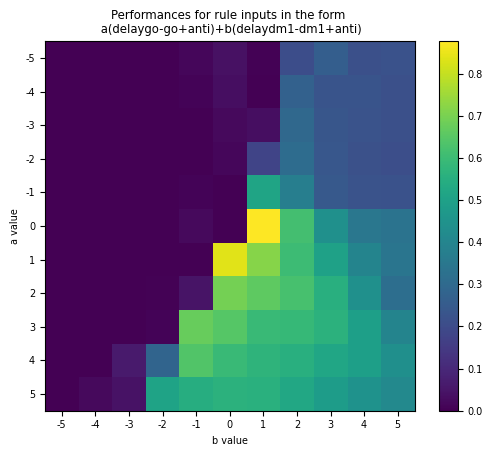

In [28]:
model_dir = './../models/fdgo_fdanti_delaygo_delaydm1_dm1_1024'
performances = np.load(os.path.join(model_dir, 'comp_rule_linear_comb_neg.npy'), allow_pickle=True)

plt.imshow(performances)
plt.xticks(np.arange(0, performances.shape[1], 1))
plt.yticks(np.arange(0, performances.shape[0], 1))
plt.gca().set_xticklabels([int(x) for x in np.linspace(-5, 5, performances.shape[1])])
plt.gca().set_yticklabels([int(x) for x in np.linspace(-5, 5, performances.shape[0])])
plt.xlabel('b value')
plt.ylabel('a value')
plt.title('Performances for rule inputs in the form \n a(delaygo-go+anti)+b(delaydm1-dm1+anti)')
plt.colorbar()

In [4]:
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
import itertools
%matplotlib widget

model_dir = './../models/fdanti_delaygo_fdgo_delaydm1_dm1_delaydm2_dm2_contextdelaydm1_contextdm1_contextdelaydm2_dm2_multidelaydm_multidm_1024'
performance_array = np.load(os.path.join(model_dir, 'comp_rule_linear_comb_2.npy'), allow_pickle=True)

values = [x / 10 for x in range(11)]
combinations = itertools.product(values, repeat=6)
valid_combinations = sum(0.8 <= sum(comb) <= 1.2 for comb in combinations)

print('Number of values in the [0.8,1.2] section:\t\t',valid_combinations)
print('Number of actual non-zero values in the 6D matrix:\t',sum([ x!=0 for x in performance_array.flatten()]))

Number of values in the [0.8,1.2] section:		 13792
Number of actual non-zero values in the 6D matrix:	 20301


Shape of 'perf': (11, 11, 11)


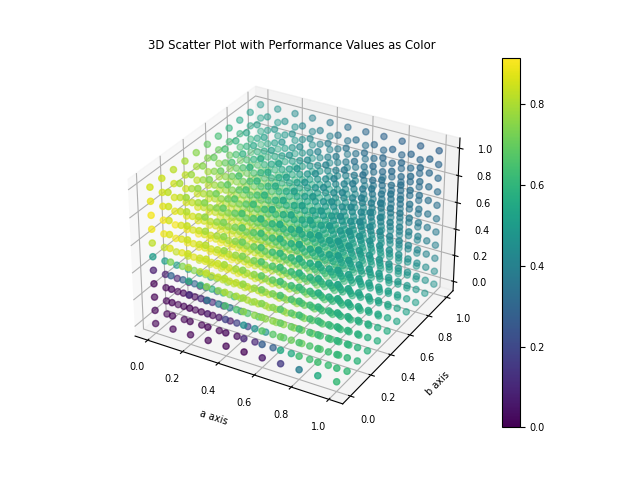

In [5]:
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
%matplotlib widget

model_dir = './../models/fdanti_delaygo_fdgo_delaydm1_dm1_delaydm2_dm2_1024'
performance_array = np.load(os.path.join(model_dir, 'comp_rule_linear_comb.npy'), allow_pickle=True)

perf=performance_array#[:,0,0,0,:,:]

print(f"Shape of 'perf': {perf.shape}")

x_dim, y_dim, z_dim = perf.shape
x = np.linspace(0,1,x_dim)
y = np.linspace(0,1,y_dim)
z = np.linspace(0,1,z_dim)

x_grid, y_grid, z_grid = np.meshgrid(x, y, z, indexing='ij')
x_vals = x_grid.flatten()
y_vals = y_grid.flatten()
z_vals = z_grid.flatten()
perf_vals = perf.flatten()

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
scat = ax.scatter(x_vals, y_vals, z_vals, c=perf_vals, cmap='viridis')
fig.colorbar(scat)
ax.set_xlabel('a axis')
ax.set_ylabel('b axis')
ax.set_zlabel('c axis')
plt.title('3D Scatter Plot with Performance Values as Color')
plt.show()

In [35]:
model_dir='./../models/fdanti_delaygo_fdgo_delaydm1_dm1_delaydm2_dm2_1024'

CA = clustering.Analysis(model_dir, data_type='rule')
CA.plot_example_unit()
CA.plot_cluster_score()
CA.plot_variance()

Unable to load data  ./../models/fdanti_delaygo_fdgo_delaydm1_dm1_delaydm2_dm2_1024/variance_rule.pkl : [Errno 2] No such file or directory: './../models/fdanti_delaygo_fdgo_delaydm1_dm1_delaydm2_dm2_1024/variance_rule.pkl'


FileNotFoundError: [Errno 2] No such file or directory: './../models/fdanti_delaygo_fdgo_delaydm1_dm1_delaydm2_dm2_1024/variance_rule.pkl'

Shape of the array: (11, 11, 11)


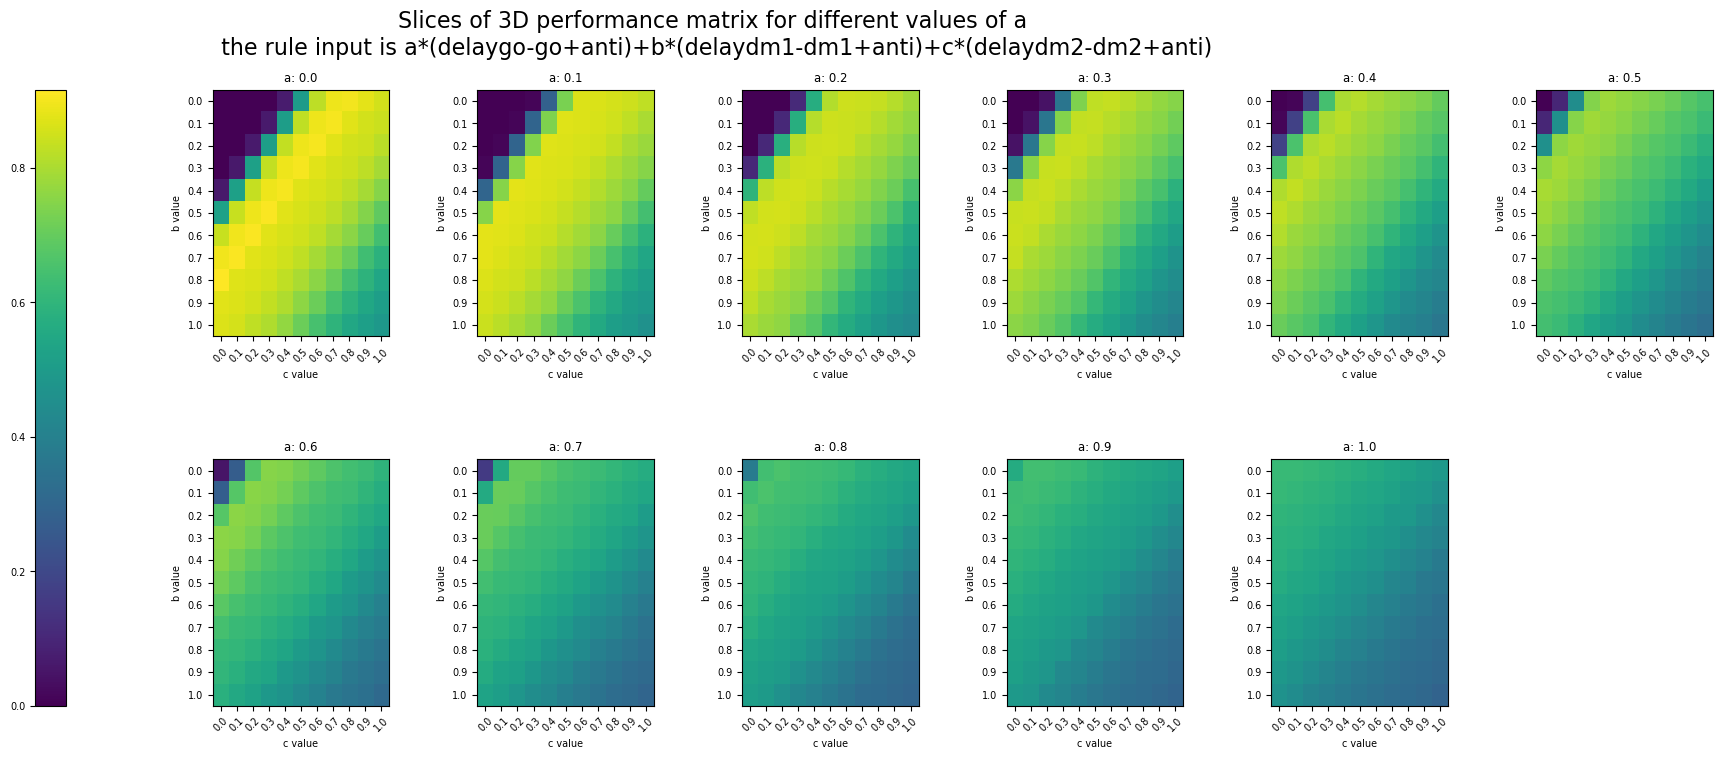

[5.55555556e-001 2.22222222e-001 2.22222222e-001 3.93764086e-030
 3.54364847e-031 2.89823477e-033 1.33138912e-033 1.55737890e-034
 3.69408130e-066 6.21504748e-067 1.88076730e-099 5.00211797e-100
 5.37295793e-133 0.00000000e+000 0.00000000e+000 0.00000000e+000
 0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
 0.00000000e+000 0.00000000e+000]
[[ 2.58198890e-01 -0.00000000e+00 -2.58198890e-01 -7.74596669e-01
  -0.00000000e+00 -0.00000000e+00  2.58198890e-01  2.58198890e-01
  -0.00000000e+00 -0.00000000e+00 -0.00000000e+00 -2.58198890e-01
  -2.58198890e-01 -0.00000000e+00 -0.00000000e+00 -0.00000000e+00
  -0.00000000e+00 -0.00000000e+00 -0.00000000e+00 -0.00000000e+00
  -0.00000000e+00 -0.00000000e+00]
 [-5.77350269e-01  1.11022302e-16  5.77350269e-01 -1.38777878e-15
  -0.00000000e+00 -0.00000000e+00  2.88675135e-01  2.88675135e-01
  -0.00000000e+00 -0.00000000e+00 -0.00000000e+00 -2.88675135e-01
  -2.88675135e-01 -0.00000000e+00 -0.00000000e+00 -0.00000000e+00
  -0.0000000

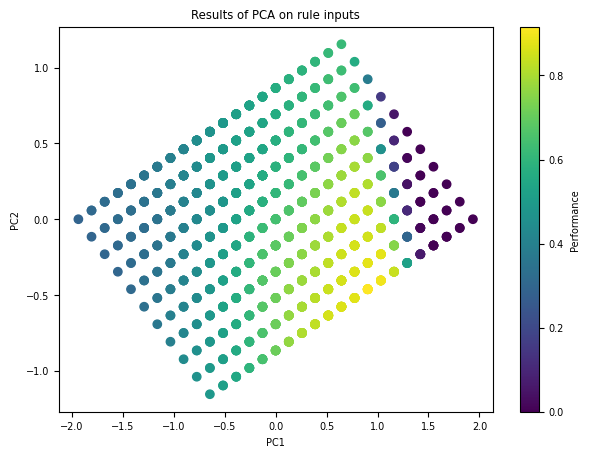

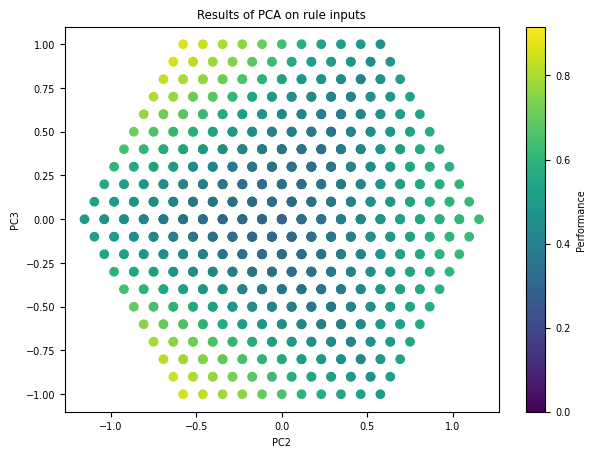

In [38]:
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib import colors
from sklearn.decomposition import PCA

model_dir = './../models/fdanti_delaygo_fdgo_delaydm1_dm1_delaydm2_dm2_1024'
performance_array = np.load(os.path.join(model_dir, 'comp_rule_linear_comb.npy'), allow_pickle=True)

print("Shape of the array:", performance_array.shape)

num_slices = performance_array.shape[0]

vmin = np.min(performance_array)
vmax = np.max(performance_array)
norm = colors.Normalize(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(2, 6, figsize=(25, 8))

for i in range(num_slices):

    ax = axes[i // 6, i % 6]
    im = ax.imshow(performance_array[i], cmap='viridis', aspect='auto', norm=norm)

    ax.set_title(f'a: {int((0.1 * i) * 10) / 10}')
    ax.set_xticks(np.arange(0, performance_array.shape[2], 1))
    ax.set_yticks(np.arange(0, performance_array.shape[1], 1))
    ax.set_xticklabels(np.round(np.linspace(0, 1, performance_array.shape[2]), 1))
    ax.set_yticklabels(np.round(np.linspace(0, 1, performance_array.shape[1]), 1))
    ax.set_xlabel('c value')
    ax.set_ylabel('b value')
    ax.tick_params(axis='x', rotation=45)

for j in range(num_slices, 12):
    ax = axes[j // 6, j % 6]
    ax.axis('off')

fig.colorbar(im, ax=axes, orientation='vertical',location='left')
plt.suptitle('Slices of 3D performance matrix for different values of a\n the rule input is a*(delaygo-go+anti)+b*(delaydm1-dm1+anti)+c*(delaydm2-dm2+anti)', fontsize=16)
plt.subplots_adjust(left=0.3,hspace=0.5, wspace=0.5)
plt.show()

grid_values = np.linspace(0, 1, 11)
rule_strengths = []
performance_values = []

for i, a in enumerate(grid_values):
    for j, b in enumerate(grid_values):
        for k, c in enumerate(grid_values):
            perf_value = performance_array[i, j, k]
            rule_strengths.append(((a*np.array([-1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0])) + 
                                    (b*np.array([0,0,0,1,0,0,-1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0])) + 
                                    (c*np.array([0,0,0,1,0,0,0,-1,0,0,0,0,1,0,0,0,0,0,0,0,0,0]))))
            performance_values.append(perf_value)

X = np.array(rule_strengths)  
y = np.array(performance_values)  

pca = PCA()
pca.fit(X)
explained_variance = pca.explained_variance_ratio_
print(explained_variance)
print(pca.components_)
mask=[explained_variance>10e-20]

X_transformed = pca.transform(X)

for i in range(2):
    pc1 = X_transformed[:, i]
    pc2 = X_transformed[:, i+1]

    plt.figure(figsize=(7, 5))
    scatter = plt.scatter(pc1, pc2, c=y, cmap='viridis')
    plt.colorbar(scatter, label="Performance")
    plt.xlabel(f"PC{i+1}")
    plt.ylabel(f"PC{i+2}")
    plt.title("Results of PCA on rule inputs")
    plt.show()

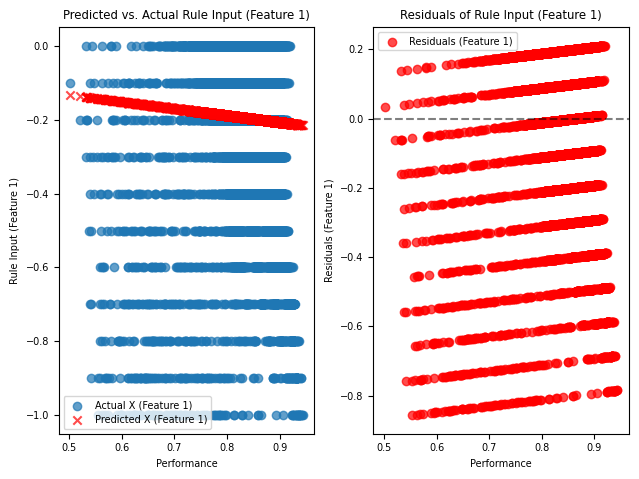

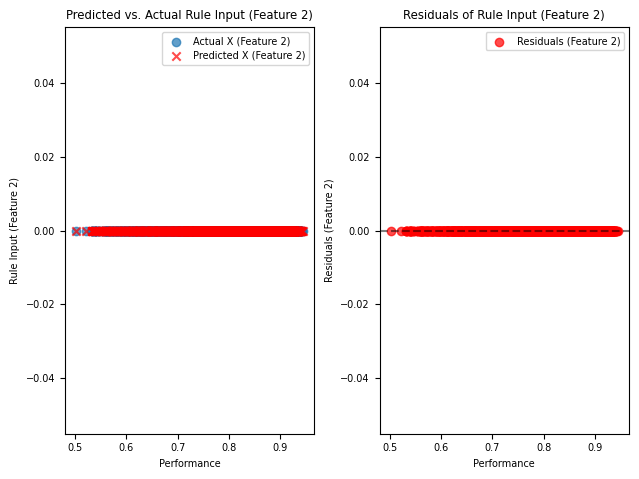

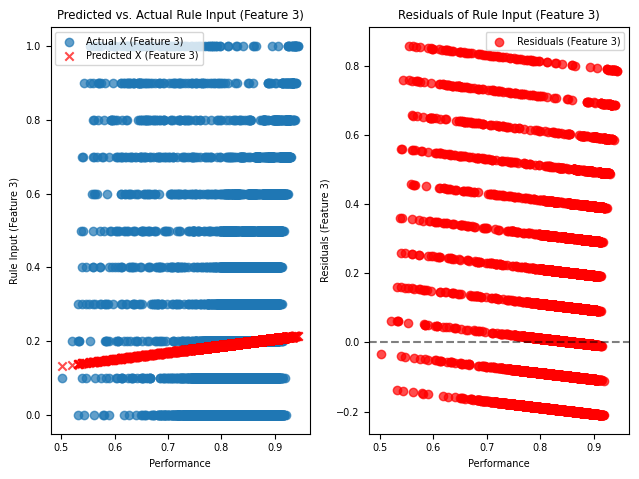

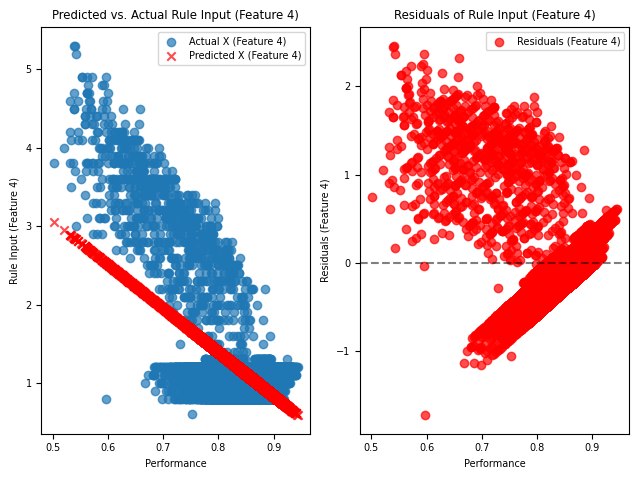

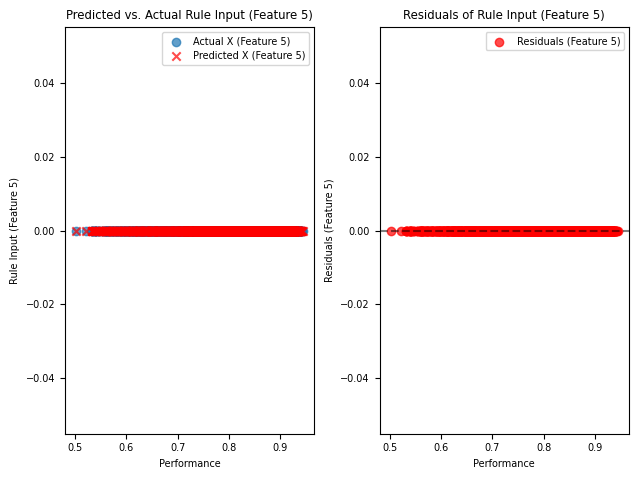

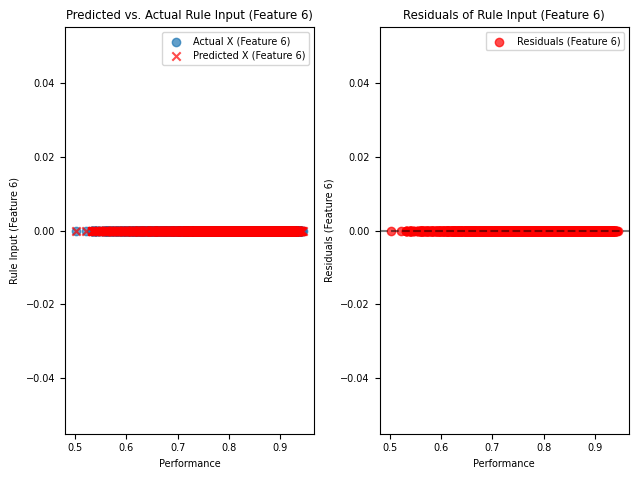

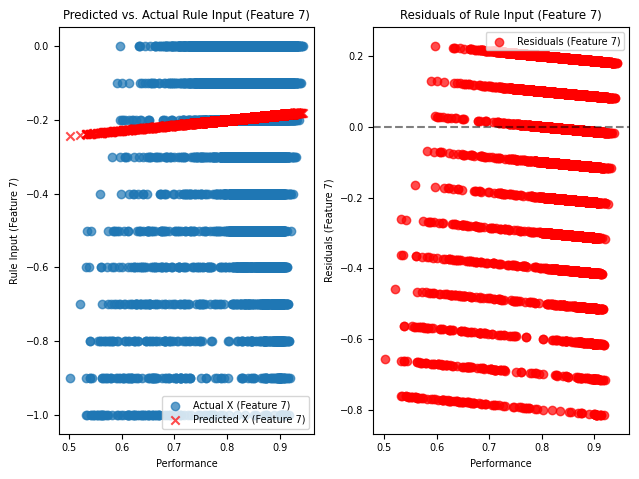

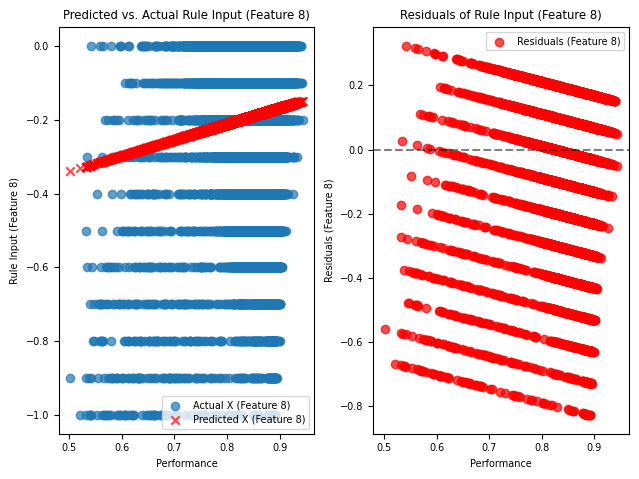

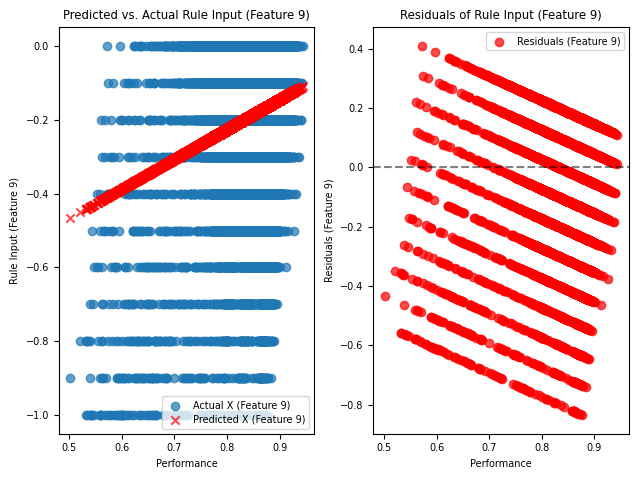

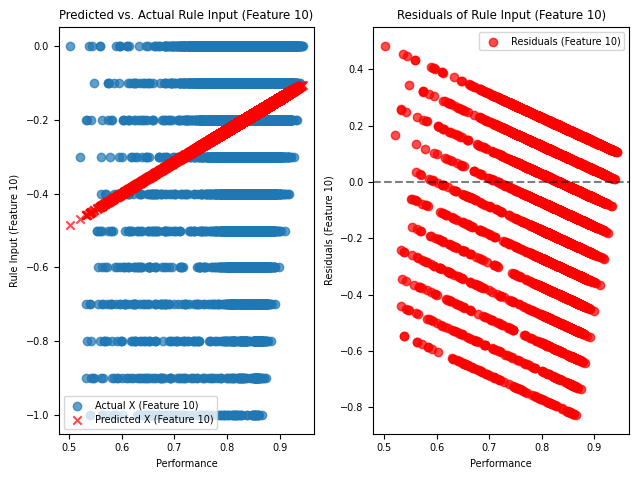

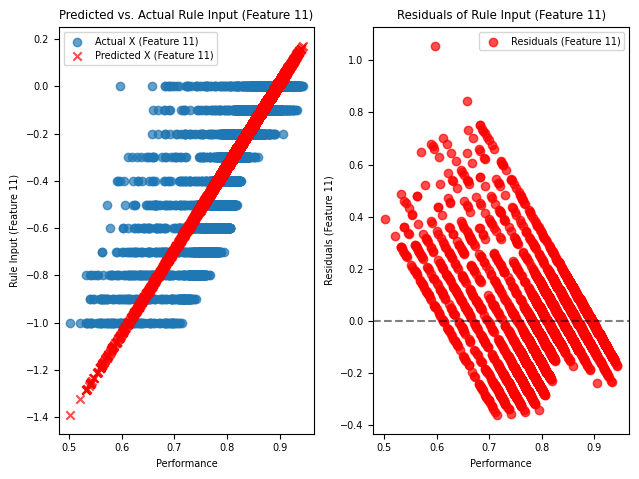

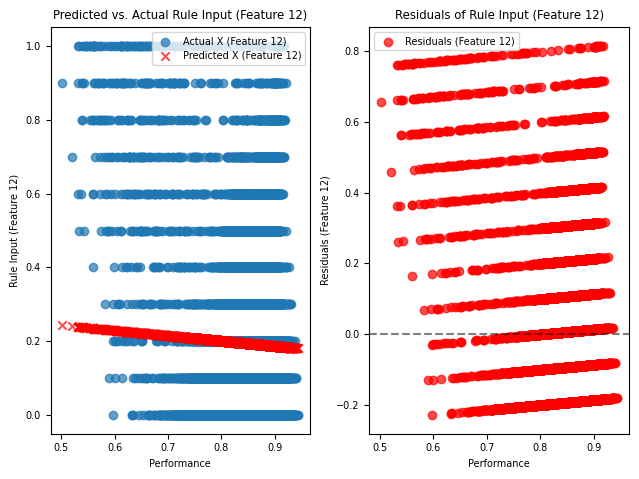

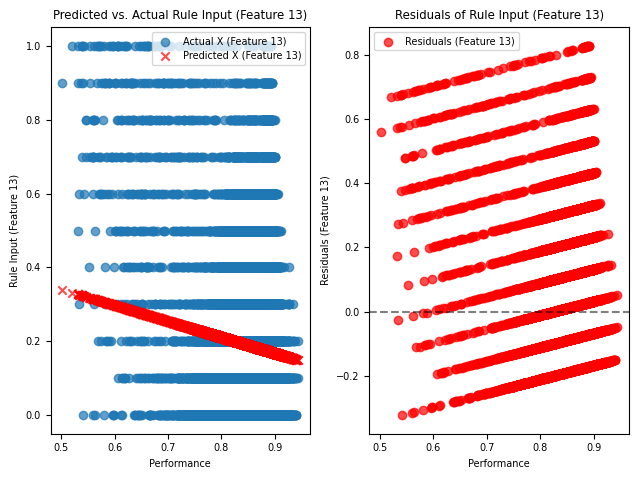

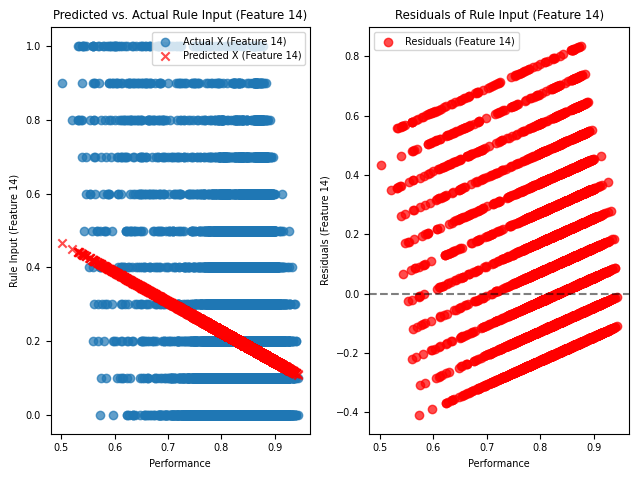

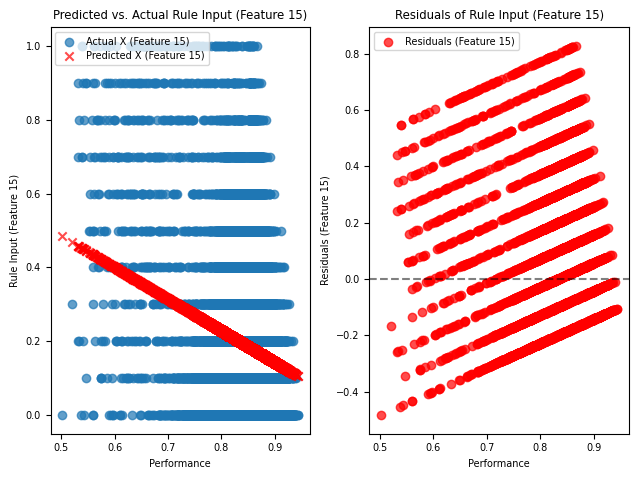

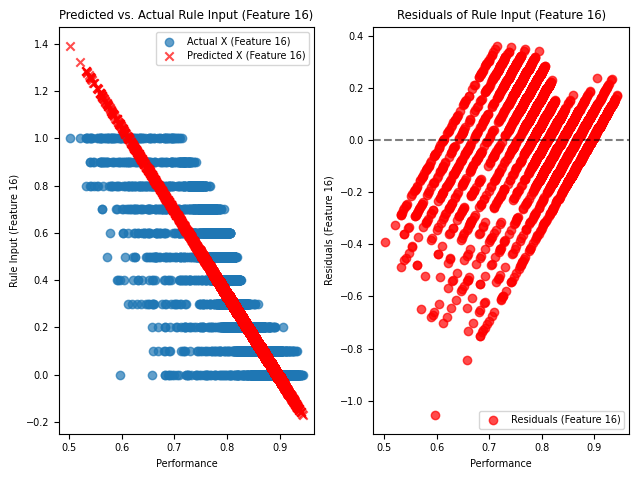

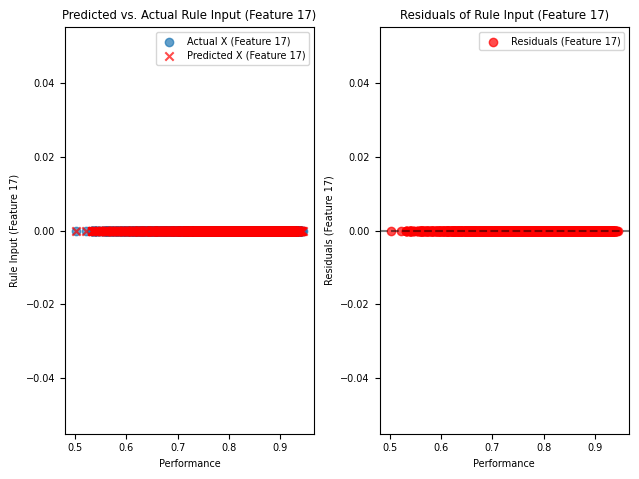

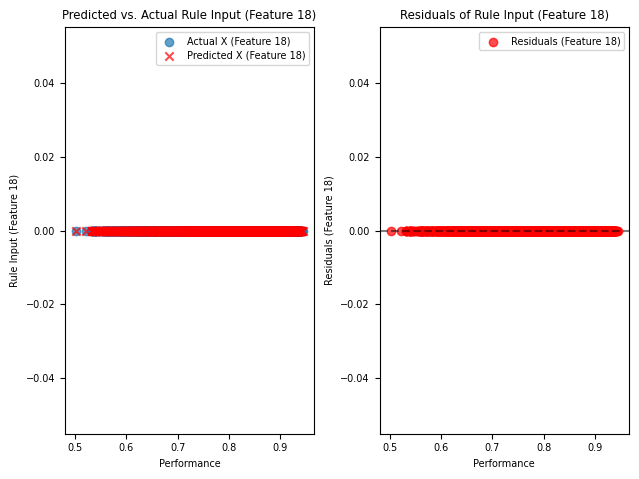

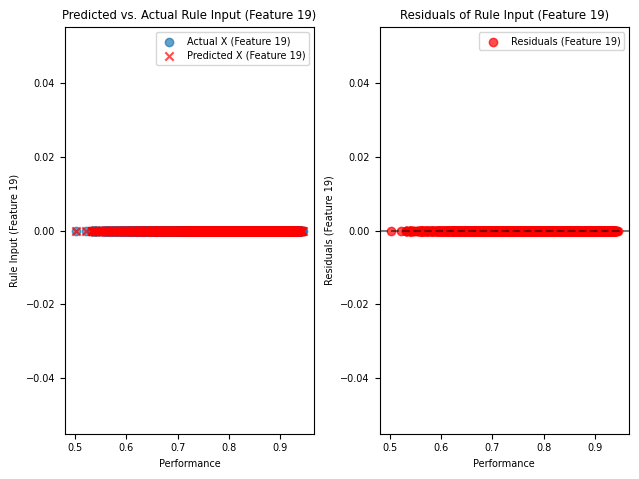

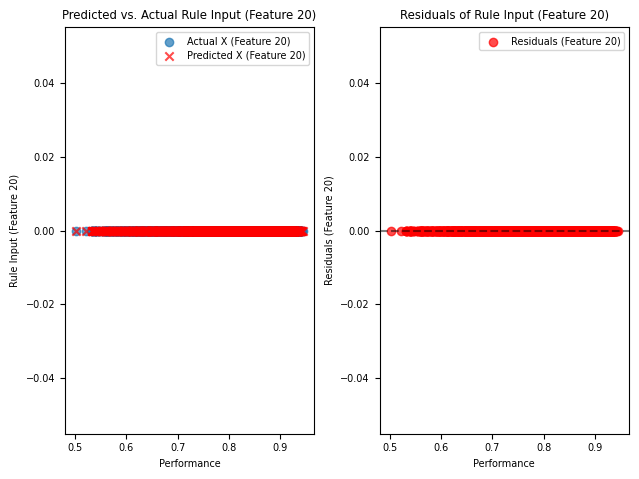

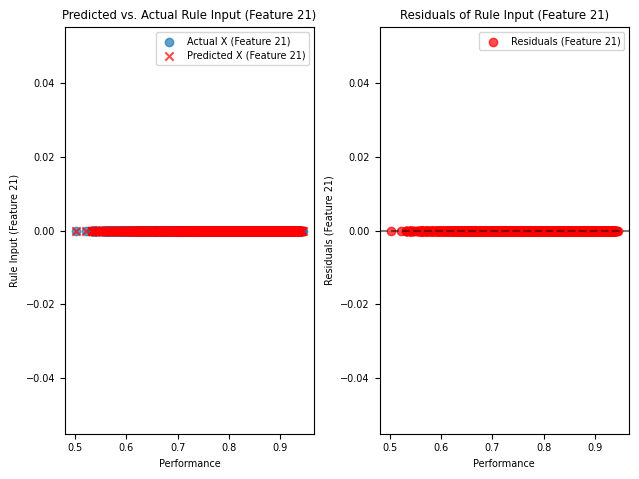

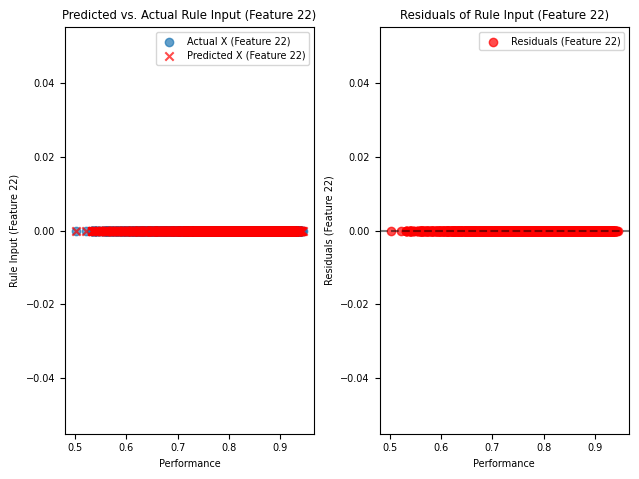

Explained variance of all PCs:  [3.62350722e-01 1.56466791e-01 1.54647041e-01 1.54325564e-01
 1.53954941e-01 1.82549413e-02 1.22072656e-31 8.39272224e-33
 5.20492822e-33 3.17126369e-33 2.22079131e-33 7.11776683e-34
 5.45017757e-34 2.23953716e-34 7.39649166e-35 6.48055870e-36
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00]
Last 6 PCs:  [[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

model_dir='./../models/fdanti_delaygo_fdgo_delaydm1_dm1_delaydm2_dm2_contextdelaydm1_contextdm1_contextdelaydm2_dm2_multidelaydm_multidm_1024'
performance_array = np.load(os.path.join(model_dir,'comp_rule_linear_comb_3.npy'),allow_pickle=True)

grid_values = np.linspace(0, 1, 11)

rule_strengths = []
performance_values = []

for i, a in enumerate(grid_values):
    for j, b in enumerate(grid_values):
        for k, c in enumerate(grid_values):
            for l, d in enumerate(grid_values):
                for m, e in enumerate(grid_values):
                    for n, f in enumerate(grid_values):
                        if performance_array[i, j, k, l, m, n]!=0:
                            perf_value = performance_array[i, j, k, l, m, n]
                            rule_strengths.append(((a*np.array([-1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0])) + 
                                                    (b*np.array([0,0,0,1,0,0,-1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0])) + 
                                                    (c*np.array([0,0,0,1,0,0,0,-1,0,0,0,0,1,0,0,0,0,0,0,0,0,0])) +
                                                    (d*np.array([0,0,0,1,0,0,0,0,-1,0,0,0,0,1,0,0,0,0,0,0,0,0])) +
                                                    (e*np.array([0,0,0,1,0,0,0,0,0,-1,0,0,0,0,1,0,0,0,0,0,0,0])) +
                                                    (f*np.array([0,0,0,1,0,0,0,0,0,0,-1,0,0,0,0,1,0,0,0,0,0,0]))))
                            performance_values.append(perf_value)

X = np.array(rule_strengths)  
y = np.array(performance_values)  

model = LinearRegression()
model.fit(y.reshape(-1, 1), X)
X_pred = model.predict(y.reshape(-1, 1))
X_residuals = X - X_pred

for i in range(len(X[0,:])):
    plt.subplot(1, 2, 1)
    plt.scatter(y, X[:, i], label=f"Actual X (Feature {i+1})", alpha=0.7)
    plt.scatter(y, X_pred[:, i], label=f"Predicted X (Feature {i+1})", alpha=0.7, marker='x', color='r')
    plt.xlabel("Performance")
    plt.ylabel(f"Rule Input (Feature {i+1})")
    plt.title(f"Predicted vs. Actual Rule Input (Feature {i+1})")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.scatter(y, X_residuals[:, i], label=f"Residuals (Feature {i+1})", alpha=0.7, color='r')
    plt.axhline(0, color='black', linestyle='--', alpha=0.5)
    plt.xlabel("Performance")
    plt.ylabel(f"Residuals (Feature {i+1})")
    plt.title(f"Residuals of Rule Input (Feature {i+1})")
    plt.legend()

    plt.tight_layout()
    plt.show()
    
pca = PCA()
pca.fit(X_residuals)
explained_variance = pca.explained_variance_ratio_

predictive_directions = pca.components_[::-1]  

print('Explained variance of all PCs: ',pca.explained_variance_ratio_)
print('Last 6 PCs: ',predictive_directions[:6])

[3.62350722e-01 1.56466791e-01 1.54647041e-01 1.54325564e-01
 1.53954941e-01 1.82549413e-02 1.22072656e-31 8.39272224e-33
 5.20492822e-33 3.17126369e-33 2.22079131e-33 7.11776683e-34
 5.45017757e-34 2.23953716e-34 7.39649166e-35 6.48055870e-36
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00]


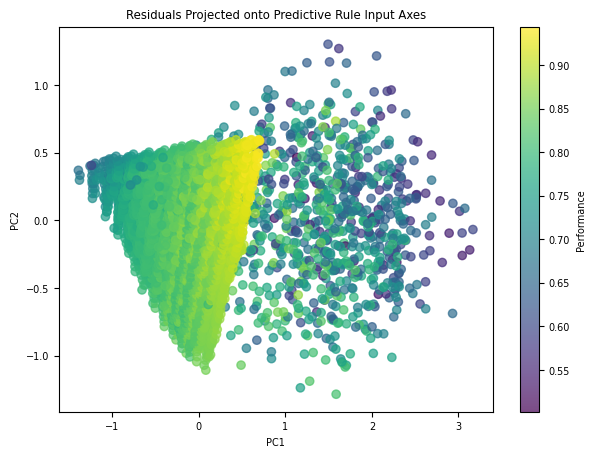

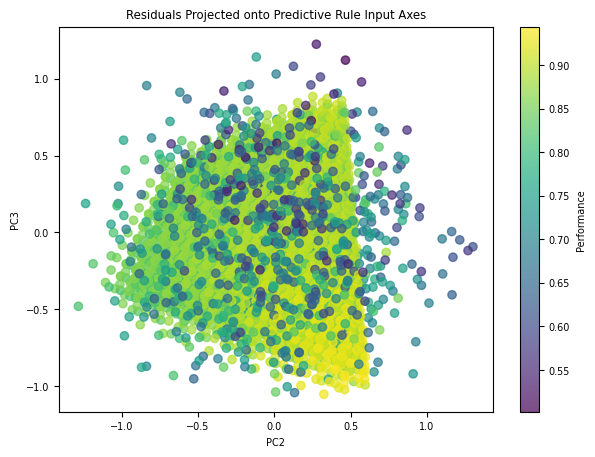

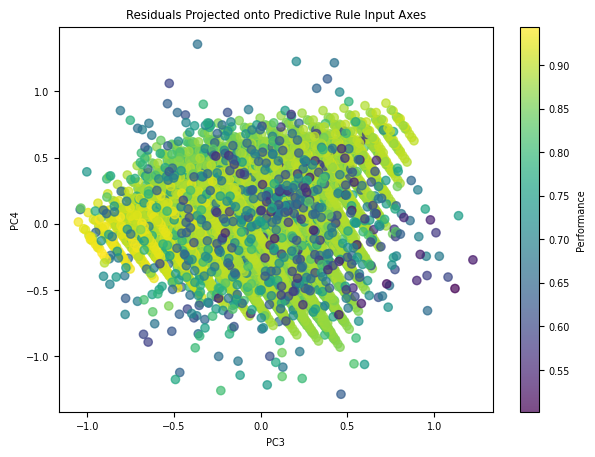

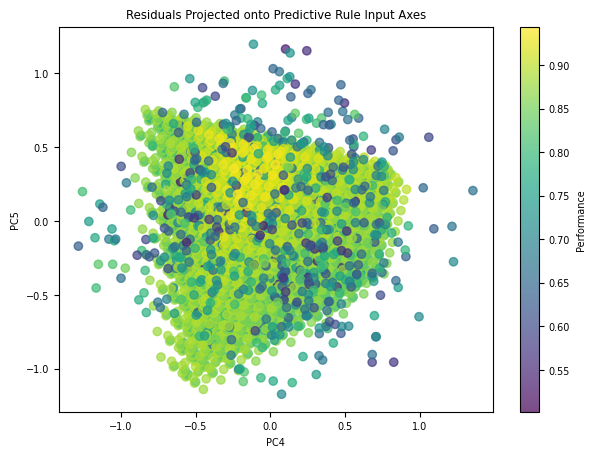

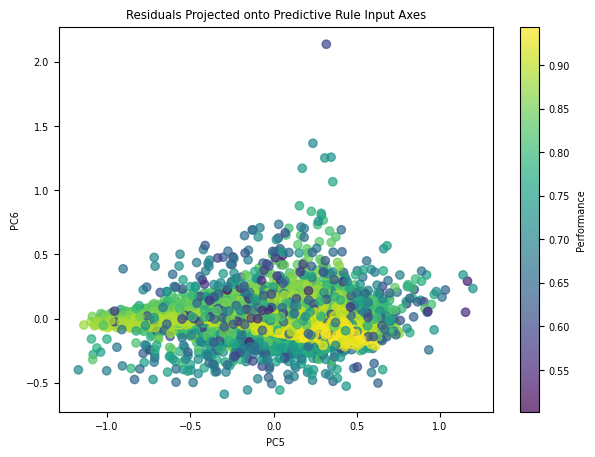

In [7]:
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

model_dir = './../models/fdanti_delaygo_fdgo_delaydm1_dm1_delaydm2_dm2_contextdelaydm1_contextdm1_contextdelaydm2_dm2_multidelaydm_multidm_1024'
performance_array = np.load(os.path.join(model_dir, 'comp_rule_linear_comb_3.npy'), allow_pickle=True)

grid_values = np.linspace(0, 1, 11)
rule_strengths = []
performance_values = []

for i, a in enumerate(grid_values):
    for j, b in enumerate(grid_values):
        for k, c in enumerate(grid_values):
            for l, d in enumerate(grid_values):
                for m, e in enumerate(grid_values):
                    for n, f in enumerate(grid_values):
                        if performance_array[i, j, k, l, m, n]!=0:
                            perf_value = performance_array[i, j, k, l, m, n]
                            rule_vector = (
                                a * np.array([-1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]) +
                                b * np.array([0, 0, 0, 1, 0, 0, -1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]) +
                                c * np.array([0, 0, 0, 1, 0, 0, 0, -1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]) +
                                d * np.array([0, 0, 0, 1, 0, 0, 0, 0, -1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]) +
                                e * np.array([0, 0, 0, 1, 0, 0, 0, 0, 0, -1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0]) +
                                f * np.array([0, 0, 0, 1, 0, 0, 0, 0, 0, 0, -1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0])
                            )
                            rule_strengths.append(rule_vector)
                            performance_values.append(perf_value)

X = np.array(rule_strengths)
y = np.array(performance_values)

model = LinearRegression()
model.fit(y.reshape(-1, 1), X)
X_pred = model.predict(y.reshape(-1, 1))
X_residuals = X - X_pred

pca = PCA()
pca.fit(X_residuals)
explained_variance = pca.explained_variance_ratio_

print(explained_variance)

X_residuals_transformed = pca.transform(X_residuals)

for i in range(5):
    pc1 = X_residuals_transformed[:, i]
    pc2 = X_residuals_transformed[:, i+1]

    plt.figure(figsize=(7, 5))
    scatter = plt.scatter(pc1, pc2, c=y, cmap='viridis', alpha=0.7)
    plt.colorbar(scatter, label="Performance")
    plt.xlabel(f"PC{i+1}")
    plt.ylabel(f"PC{i+2}")
    plt.title("Residuals Projected onto Predictive Rule Input Axes")
    plt.show()